# Explore from first principles daily reforecast of financial time series group question

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
import matplotlib.pylab as plt

## Get all questions

In [3]:
from get_market_pulse_25q3_questions import get_market_pulse_25q3_questions
ifps = get_market_pulse_25q3_questions()

200


In [4]:
import json
if 0:
    from get_underlying_urls import get_underlying_urls
    results = get_underlying_urls(ifps)
    with open('results.json', 'w') as f:
        json.dump(results, f, indent=4)
else:
    with open('results.json', 'r') as f:
        results = json.load(f)

## Acquire question data

In [5]:
from urls_to_ticker import urls_to_ticker
from pprint import pprint
sources = []
for key, (title, urls) in results.items():
    print(title)
    sources.extend(urls_to_ticker(urls))
    pprint(urls)

What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025?
['https://en.wikipedia.org/wiki/VIX',
 'https://www.tradingview.com/symbols/CBOE-VIX/',
 'https://www.cboe.com/tradable_products/vix/vix_historical_data/']
What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods?
['https://fred.stlouisfed.org/series/BAMLH0A0HYM2']
How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025?
['https://companiesmarketcap.com/',
 'https://finance.yahoo.com/quote/NVDA/history/',
 'https://finance.yahoo.com/quote/AAPL/history/']
How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025?
['https://companiesmarketcap.com/',
 'https://finance.yahoo.com/quote/NVDA/history/',
 'https://finance.yahoo.com/quote/MSFT/history/']
How much will Crude Oil Futures total price returns exceed S&P 500 Futures's in the follo

In [6]:
sources = list(sorted(set(sources)))

In [7]:
import os, joblib
from get_data_for import get_data_for
if os.path.exists('history.joblib'):
    history = joblib.load('history.joblib')
else:
    history = {(x,y,z): get_data_for(x,y,z) for x,y,z in sources}
    joblib.dump(history, 'history.joblib');

In [8]:
group_id_to_data = {int(x): results[x] for x in results}

In [9]:
results = {int(key): value for key, value in results.items()}

In [10]:
for ifp in ifps:
    ifp['sources'] = urls_to_ticker(results[ifp['group']['id']][1])
    ifp['data'] = {x: history[x] for x in ifp['sources']}
    if 'following companies' in ifp['title']:
        company = ifp['title'].split('(')[1].split(')')[0]
        ifp['sources'] = [(x,y,z) for x,y,z in ifp['sources'] if y == company]
        ifp['data'] = {(x,y,z):w for (x,y,z),w in ifp['data'].items() if y == company}

## Get forward period start and end date

In [11]:
from get_forward_period_start_and_end_date import get_forward_period_start_and_end_date

In [13]:
for ifp in ifps:
    ifp['period'] = get_forward_period_start_and_end_date(ifp)

START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.2841763178507487

```python
["2025-07-21", "2025-08-01"]
```
START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.016557617982228597

```python
["2025-08-04", "2025-08-15"]
```
START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.01643460194269816

```python
["2025-07-21", "2025-08-01"]
```
START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.016754706700642902

```python
["2025-08-04", "2025-08-15"]
```
START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.016179279486338297

```python
["2025-07-21", "2025-08-01"]
```
START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.0160466790199279

In [14]:
for ifp in ifps:
    print(ifp['title'])
    print(ifp['period'] if type(ifp['period']) == str else '\n'.join(ifp['period']))
    print()

What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (July 21 - Aug 1)
2025-07-21
2025-08-01

What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (Aug 4 - Aug 15)
2025-08-04
2025-08-15

What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Jul 21 - Aug 1)
2025-07-21
2025-08-01

What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Aug 4 - Aug 15)
2025-08-04
2025-08-15

How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
2025-07-21
2025-08-01

How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15)
2025-08-04
2025-08-15

How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025? (Jul 

## Parse observable of data

In [15]:
from get_observable import get_observable
import pandas as pd
pd.set_option('display.max_colwidth', 1000)

In [16]:
from get_period_type import get_period_type

In [17]:
rows = []
for i, ifp in enumerate(ifps):
    ifp['observable'] = get_observable(ifp)
    ifp['period_type'] = get_period_type(ifp)
    rows.append((ifp['id'], ifp['observable'], ifp['period'], ifp['period_type'], ifp['title']))
df = pd.DataFrame(rows, columns = ['id', 'observable', 'forward period', 'period_type', 'title'])
df

,id,observable,forward period,period_type,title
0,37926,High,"[2025-07-21, 2025-08-01]",any day in biweekly period,"What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (July 21 - Aug 1)"
1,38212,High,"[2025-08-04, 2025-08-15]",any day in biweekly period,"What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (Aug 4 - Aug 15)"
2,37932,Close,"[2025-07-21, 2025-08-01]",last day of biweekly period,What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Jul 21 - Aug 1)
3,38213,Close,"[2025-08-04, 2025-08-15]",last day of biweekly period,What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Aug 4 - Aug 15)
4,37964,stock price Close return,"[2025-07-21, 2025-08-01]",return on last vs first day of biweekly period,How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
5,38207,stock price Close return,"[2025-08-04, 2025-08-15]",return on last vs first day of biweekly period,How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15)
6,37972,stock price Close return,"[2025-07-21, 2025-08-01]",return on last vs first day of biweekly period,How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
7,38208,stock price Close return,"[2025-08-04, 2025-08-15]",return on last vs first day of biweekly period,How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15)
8,37978,futures total price Close return,"[2025-07-21, 2025-08-01]",return on last vs first day of biweekly period,How much will Crude Oil Futures total price returns exceed S&P 500 Futures's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
9,38209,futures total price Close return,"[2025-08-04, 2025-08-15]",return on last vs first day of biweekly period,How much will Crude Oil Futures total price returns exceed S&P 500 Futures's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15)


## Compute function on observables

### High on any day in forward biweekly period from today

What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (July 21 - Aug 1)


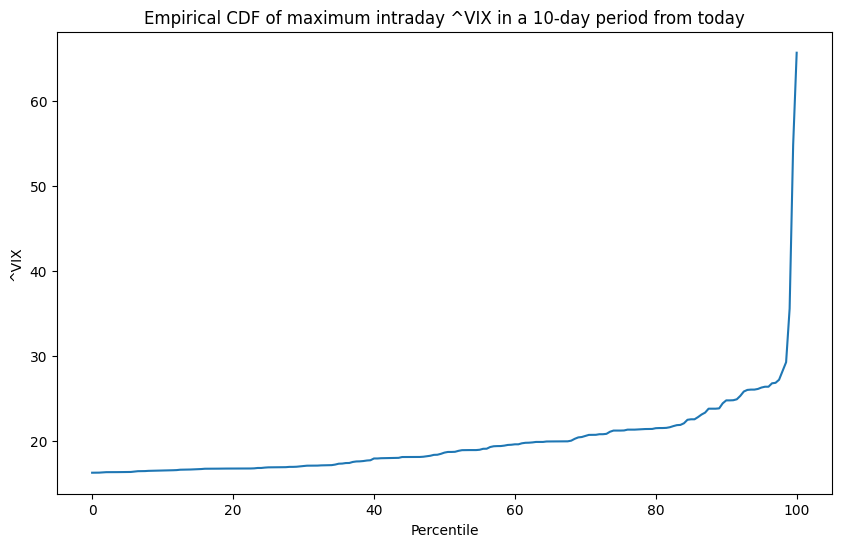

In [21]:
from datetime import datetime
import numpy as np
from estimate_conditional_percentiles import estimate_conditional_percentiles

ifp = ifps[0]
print(ifp['title'])
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]][ifp['observable']]
today = datetime.now()
start_date, end_date = [datetime.strptime(date_str, "%Y-%m-%d") for date_str in period]
lookahead = np.busday_count(today.strftime('%Y-%m-%d'), start_date.strftime('%Y-%m-%d'))
A = data.values.T[0]
biweekly = 10
rng, forecast = estimate_conditional_percentiles(A, window=biweekly, gap=lookahead, Y=A[-1], epsilon=0.5)
plt.figure(figsize=(10,6))
plt.plot(rng, forecast);
underlying = ifp['sources'][0][1]
plt.ylabel(underlying)
plt.xlabel('Percentile')
plt.title(f'Empirical CDF of maximum intraday {underlying} in a 10-day period from today');

### Close on last day of biweekly period

What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Jul 21 - Aug 1)
('last day of biweekly period', ['2025-07-21', '2025-08-01'], 'Close')


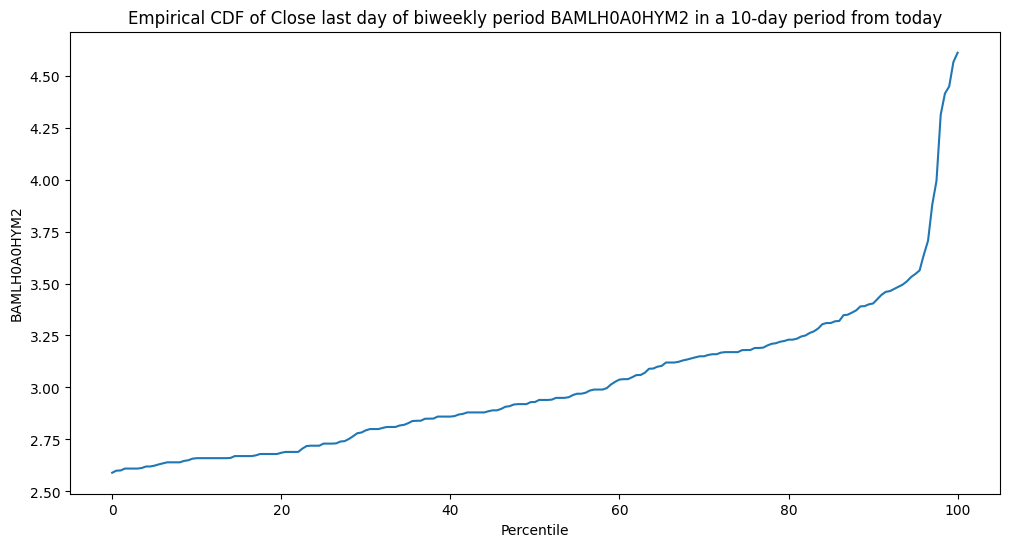

In [35]:
from estimate_conditional_percentiles_OAS import estimate_conditional_percentiles_OAS

ifp = ifps[2]
print(ifp['title'])
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]]
today = datetime.now()
print((period_type, period, observable))
start_date, end_date = [datetime.strptime(date_str, "%Y-%m-%d") for date_str in period]
lookahead = max(1, np.busday_count(today.strftime('%Y-%m-%d'), start_date.strftime('%Y-%m-%d')))
A = data.values
A = A[~np.isnan(A)]
biweekly = 10
rng, forecast = estimate_conditional_percentiles_OAS(A, window=biweekly, gap=lookahead, Y=A[-1], epsilon=0.5)
plt.figure(figsize=(12,6))
plt.plot(rng, forecast);
underlying = ifp['sources'][0][1]
plt.ylabel(underlying)
plt.xlabel('Percentile')
plt.title(f'Empirical CDF of {observable} {period_type} {underlying} in a 10-day period from today');

### period stock price return on last vs first day of biweekly period

How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
('return on last vs first day of biweekly period', ['2025-07-21', '2025-08-01'], 'stock price Close return')


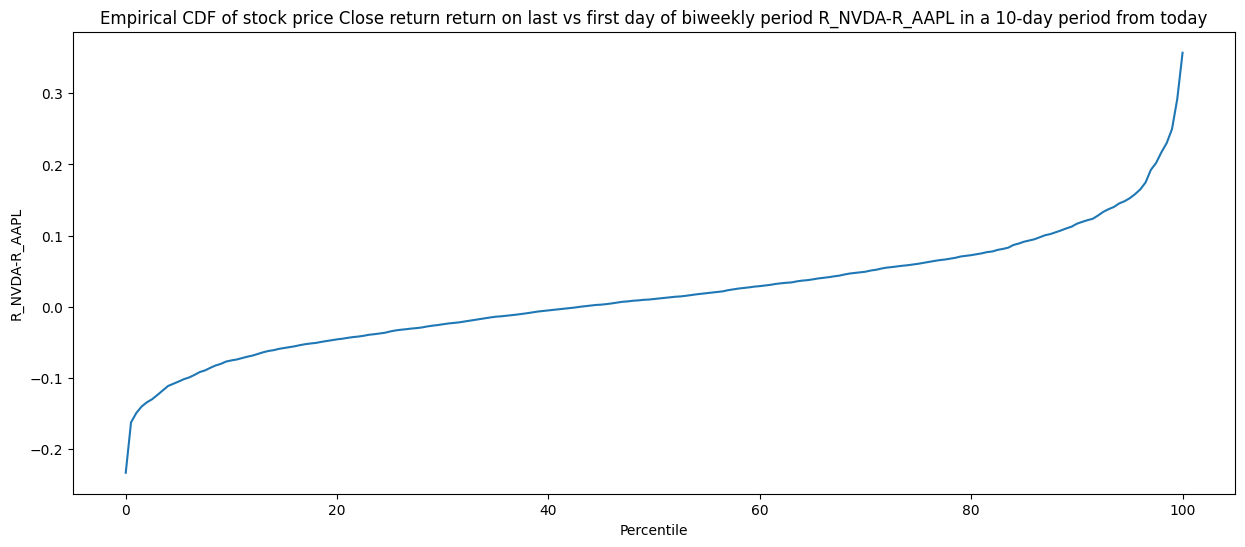

In [47]:
from estimate_conditional_diff_percentiles import estimate_conditional_diff_percentiles

ifp = ifps[4]
print(ifp['title'])
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data']
today = datetime.now()
print((period_type, period, observable))
A2 = data[('yahoo','NVDA','price')]['Close'].values
A1 = data[('yahoo','AAPL','price')]['Close'].values
start_date, end_date = [datetime.strptime(date_str, "%Y-%m-%d") for date_str in period]
lookahead = np.busday_count(today.strftime('%Y-%m-%d'), start_date.strftime('%Y-%m-%d'))
biweekly = 10
underlying = f'R_{ifp['sources'][0][1]}-R_{ifp['sources'][1][1]}'
rng, forecast = estimate_conditional_diff_percentiles(A1, A2, window=biweekly, gap=lookahead, epsilon=0.5)
plt.figure(figsize=(15,6))
plt.plot(rng, forecast);
plt.ylabel(underlying)
plt.xlabel('Percentile')
plt.title(f'Empirical CDF of {observable} {period_type} {underlying} in a 10-day period from today');

### period futures total price return on last vs first day of biweekly period

In [ ]:
ifp = ifps[13]

In [59]:
prompt = f"""Consider the question: {ifp['title']}

Suppose that today is July 18th.

I have an array A1 of Gold Futures prices for the last 15 years up to July 17th.  
I have an array A2 of S&P 500 Futures prices for the last 15 years up to July 17th.  
There are 10 business days to August 4, the beginning of a 10 business day observation period that goes to August 1.

Construct from A1 the array R1 of rolling total price returns of Gold Futures prices for a 10-day observation period.  Similarly construct R2 from A2.  The rules for constructing the total price returns are as follows:

{ifp['group']['group_of_questions']['resolution_criteria']}

{ifp['group']['group_of_questions']['fine_print']}


Estimate R2(Aug 4 - Aug 15)-R1(Aug 4 - Aug 15) conditional on the most recent returns R1[-1] and R2[-1].

Write a Python function to return the 201-element percentile array rng = np.arange(0,100.5, 0.5) and the percentile value of R2(Aug 4 - Aug 15)-R1(Aug 4 - Aug 15)  | R1[-1] and R2[-1] on those percentile points."""

In [ ]:
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data']
title, observable, period_type, period, data 

("How much will Gold Futures total price returns exceed S&P 500 Futures's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15)",
 'futures total price Close return',
 'return on last vs first day of biweekly period',
 ['2025-08-04', '2025-08-15'],
 {('yahoo',
   'GC%3DF',
   'price'): Price             Close         High          Low         Open Volume
  Ticker           GC%3DF       GC%3DF       GC%3DF       GC%3DF GC%3DF
  Date                                                                 
  2015-07-21  1103.400024  1106.400024  1097.099976  1097.099976    118
  2015-07-22  1091.400024  1095.000000  1086.000000  1093.000000     46
  2015-07-23  1094.000000  1097.599976  1087.800049  1097.400024     64
  2015-07-24  1085.599976  1100.699951  1078.599976  1078.599976     52
  2015-07-27  1096.500000  1102.500000  1093.900024  1100.000000     19
  ...                 ...          ...          ...          ...    ...
  2025-07-14  3351.500000  3375.500000  3350.000000  3367.

In [61]:
from conditional_difference_distribution import conditional_difference_distribution

In [88]:
A2 = data[ifp['sources'][0]]['Close'].values.T[0]
A1 = data[ifp['sources'][1]]['Close'].values.T[0]
start_date, end_date = [datetime.strptime(date_str, "%Y-%m-%d") for date_str in period]
lookahead = np.busday_count(today.strftime('%Y-%m-%d'), start_date.strftime('%Y-%m-%d'))
biweekly = 10
underlying = f'R_{ifp['sources'][0][1]}-R_{ifp['sources'][1][1]}'

In [89]:
start_date, end_date, lookahead

(datetime.datetime(2025, 8, 4, 0, 0), datetime.datetime(2025, 8, 15, 0, 0), 10)

In [100]:
rng, forecast, sample_diffs, pct_of_zero = conditional_difference_distribution(A1, A2, window=biweekly, gap=lookahead, epsilon=0.1)

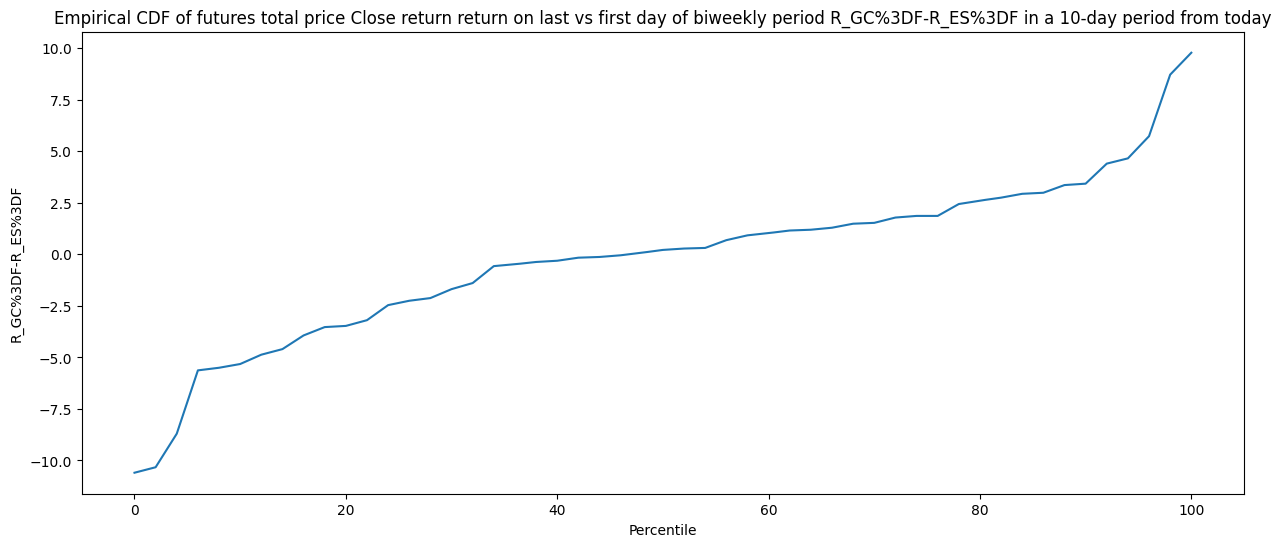

In [101]:
plt.figure(figsize=(15,6))
plt.plot(rng, forecast);
plt.ylabel(underlying)
plt.xlabel('Percentile')
plt.title(f'Empirical CDF of {observable} {period_type} {underlying} in a 10-day period from today');

### quarter diluted eps on next SEC filing date	

In [108]:
from forecast_next_quarter_measure import forecast_next_quarter_measure

In [105]:
ifp = ifps[16]
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]].dropna()
title, observable, period_type, period, data 

('What will the first reported earnings per share after June 2025 be for the following companies? (TSLA)',
 'quarter diluted eps',
 'next SEC filing date',
 '2025-09-30',
 2024-03-31    0.34
 2024-06-30    0.42
 2024-09-30    0.62
 2024-12-31    0.66
 2025-03-31    0.12
 Name: Diluted EPS, dtype: float64)

In [110]:
forecast_next_quarter_measure(data)

{'Naive': 0.12,
 'Average': 0.43200000000000005,
 'Drift': 0.06499999999999999,
 'Linear Regression': 0.3720000000000001,
 'Median': 0.24600000000000005}

### quarter total revenue on next SEC filing date	

In [111]:
ifp = ifps[25]
title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]]
title, observable, period_type, period, data 

('What will the first reported revenues after June 2025 be for the following companies? (MSFT)',
 'quarter total revenue',
 'next SEC filing date',
 '2025-09-30',
 2024-03-31    6.185800e+10
 2024-06-30    6.472700e+10
 2024-09-30    6.558500e+10
 2024-12-31    6.963200e+10
 2025-03-31    7.006600e+10
 Name: Total Revenue, dtype: float64)

In [112]:
forecast_next_quarter_measure(data)

{'Naive': 70066000000.0,
 'Average': 66373600000.0,
 'Drift': 72118000000.0,
 'Linear Regression': 72769900000.0,
 'Median': 71092000000.0}

## Forecast the question

## Submit the question

## Repeat until all questions are forecast

## Automate and rerun

## Assess crowd alignment

In [ ]:
ifp['group']['group_of_questions'].keys()

In [ ]:
print(ifp['group']['group_of_questions']['resolution_criteria'])

In [ ]:
vix = ifp['inputs'][('yahoo', '^VIX', 'price')]

In [ ]:
ifp['title']

In [ ]:
vix['Close']['^VIX'].plot();

In [ ]:
df_vix = vix[['High']]

In [ ]:
df_vix.columns = ['^VIX']

In [ ]:
ifp['title']

In [ ]:
today = str(datetime.now())[0:10]
today

In [ ]:
future_start = '2025-07-21'
future_end = '2025-08-01'

In [ ]:
cdf_vix = conditional_future_vix_max_cdf(
    df_vix,             # DataFrame with Date index & column '^VIX'
    today,                   # Today's date as 'YYYY-MM-DD'
    future_start,            # Start of window as 'YYYY-MM-DD'
    future_end,              # End of window as 'YYYY-MM-DD'
    band=0.5                # Conditioning band in VIX units, e.g. ±0.5
)

In [ ]:
pdf_vix = cdf_to_pdf(cdf_vix)

In [ ]:
percentiles = np.arange(0,100.5,0.5)

In [ ]:
plt.plot(percentiles, pdf_vix);

In [ ]:
%matplotlib inline
import matplotlib.pylab as plt
plt.plot(percentiles, cdf_vix);